In [2]:
import yaml
from ultralytics import YOLO
from torch.cuda import is_available
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.model_utils import smart_predict
from src.generate_report import generate_report

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
s2_data = r'..\Data\Processed\Stage 2 (Enumeration Detection)\\'
s2_data_yaml_path = os.path.join(s2_data,'data.yaml')

s2_data_output = r'..\Runs\Stage 2\\'

In [4]:
config = {
    'data': s2_data_yaml_path,
    'epochs': 100,
    'save': True,
    'imgsz': 768,
    'batch': 16,
    'patience': 20,
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'lrf': 0.01,
    'plots': True,
    'verbose': True,
    'device': 'cuda' if is_available() else 'cpu',
    'workers': 4,
    'project': 'Runs',
    'name': 'Stage 2',
    'save_dir': s2_data_output,
    'auto_augment': None,
    'augment': False,
    'mosaic': 0.0,
    'mixup': 0.0,
    'copy_paste': 0.0,
    'cutmix': 0.0,
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.0,
    'degrees': 0.0,
    'translate': 0.0,
    'scale': 0.0,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.0,
    'erasing': 0.0,
}

In [5]:
with open(s2_data_yaml_path,'r') as f:

    data_yaml = yaml.safe_load(f)

data_yaml

{'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 2 (Enumeration Detection)\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 2 (Enumeration Detection)\\valid\\images',
 'test': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 2 (Enumeration Detection)\\test\\images',
 'nc': 1,
 'names': ['Tooth']}

In [6]:
yolo_model = YOLO('../Models/yolo26s.pt')

In [ ]:
yolo_model.train(**config)

New https://pypi.org/project/ultralytics/8.4.96 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.83  Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Data\Processed\Stage 2 (Enumeration Detection)\\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../Models/yolo26s.pt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000216EBD19C50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

: 

In [6]:
tooth_model_detection = YOLO(os.path.join(s2_data_output,'weights','best.pt'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_447.png: 384x768 32 Tooths, 54.7ms
Speed: 9.4ms preprocess, 54.7ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Tooth
Coordinates: [1761.797119140625, 764.8133544921875, 1991.7691650390625, 1033.398681640625]
Confidence: %95.0
Class Name: Tooth
Coordinates: [1655.96044921875, 455.19122314453125, 1750.26220703125, 745.62060546875]
Confidence: %95.0
Class Name: Tooth
Coordinates: [826.764892578125, 485.73681640625, 975.2739868164062, 734.298828125]
Confidence: %95.0
Class Name: Tooth
Coordinates: [1931.36376953125, 463.1323547363281, 2070.66357421875, 719.802978515625]
Confidence: %95.0
Class Name: Tooth
Coordinates: [1897.0806884765625, 739.4860229492188, 2124.98779296875, 1005.9947509765625]
Confidence: %95.0
Class Name: Tooth
Coordinates: [656.57861328125, 704.1744995117188, 899.3874511

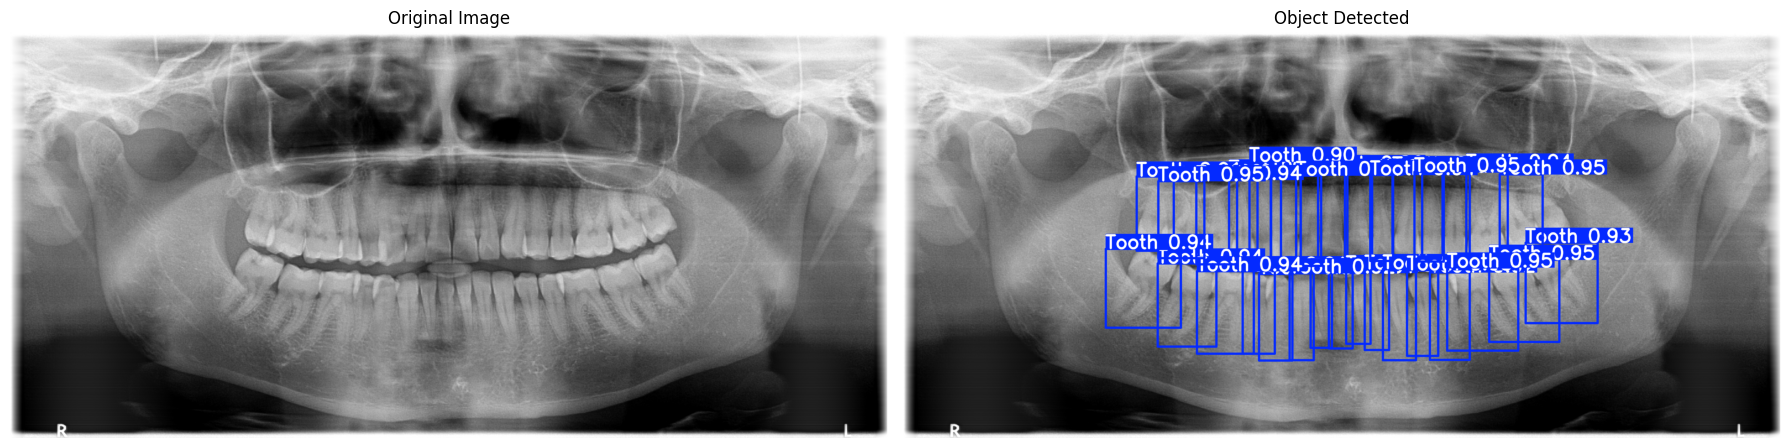

In [7]:
smart_predict(tooth_model_detection,data_yaml['test'])